# Constant Step Size vs. Sample Average in a Non-Stationary Bandit

- This notebook compares two ε-greedy agents on a **non-stationary** 10-armed bandit, where the true action-values drift over time. One agent uses the standard sample-average update (step size = 1/t), and the other uses a **constant step size (α = 0.1)**.

- Each agent is run for 2,000 independent runs of 10,000 steps (matching the setup from Sutton & Barto's RL book), to see how each update rule handles a changing environment over the long run.

In [ ]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt


module_path = Path.cwd().parent.resolve()

if str(module_path) not in sys.path:
    sys.path.append(str(module_path))


from bandit_engine import gaussian_arms_factory
from agents import EpsilonGreedyAgent
from run_experiments import compare_agents
from utils import plot_bandit_performance

In [4]:
RANDOM_SEED = 42
k_arms = 10

agent_configs = [
    {
        "label": "step-size 1/t",
        "agent_type": EpsilonGreedyAgent,
        "agent_config": {
            "n_arms": k_arms,
            "epsilon": 0.1,
            "initial_value": 0.0
        }
    },
    {
        "label": f"constant step size - alpha = 0.1",
        "agent_type": EpsilonGreedyAgent,
        "agent_config": {
            "n_arms": k_arms,
            "epsilon": 0.1,
            "initial_value": 0.0,
            "alpha": 0.1
        }
    }
]

# Set experiment parameters and run comparison
n_runs = 2000
n_steps = 10000
non_stationary = True

results = compare_agents(
    arm_factory=gaussian_arms_factory,
    agent_configs=agent_configs,
    random_seed=RANDOM_SEED,
    n_runs=n_runs,
    n_steps=n_steps,
    non_stationary=non_stationary
)

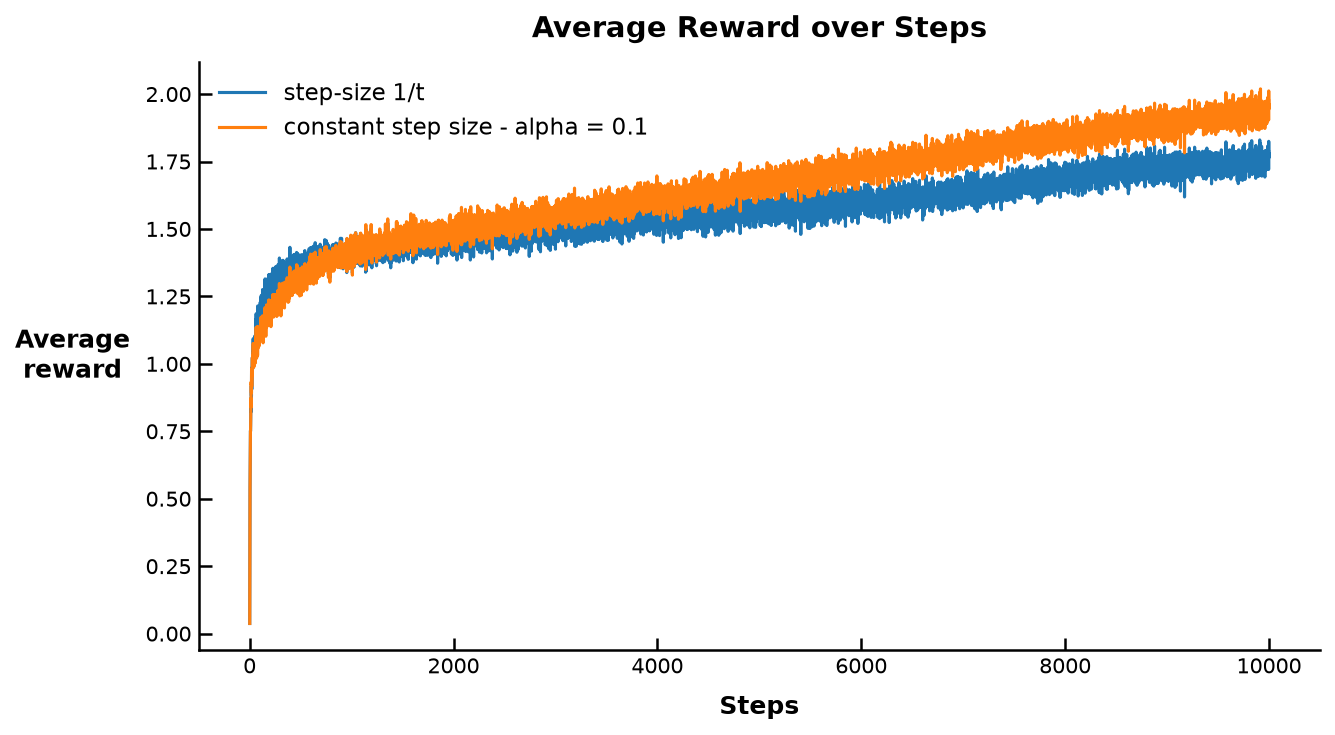

In [ ]:
# Unpack the results tuple into separate dictionaries for each metric
rewards_dict = {label: data[0] for label, data in results.items()}
optimal_actions_dict = {label: data[1] for label, data in results.items()}

# Custom color mapping matching the agent labels used in agent_configs
custom_colors = {
    "Step size 1/t": "#1F77B4",
    "Constant step size": "#FF7F0E"
}

fig_reward, ax_reward = plot_bandit_performance(
    metrics_data=rewards_dict,
    metric_type="reward",
    title="Average Reward over Steps",
    colors=custom_colors
)

plt.show()

## Observations:
- In a non-stationary environment, older rewards become less representative of the current true action-values as the environment drifts over time, so recent rewards should matter more when updating estimates. The constant step-size agent (α = 0.1) achieves this naturally: each update gives an exponentially decaying weight to past rewards, so distant observations are gradually "forgotten" while recent observations dominate the estimate. This lets the agent track the moving true values more closely, which is why it achieves a higher average reward over the run.
- In contrast, the sample-average agent (step-size 1/t) weights every past reward equally. As t grows, its step size shrinks toward zero, so its estimates become increasingly slow to update and effectively "freeze" based on a long history that includes many outdated rewards — reducing its ability to track the non-stationary environment and resulting in a lower average reward than the constant-step-size agent.

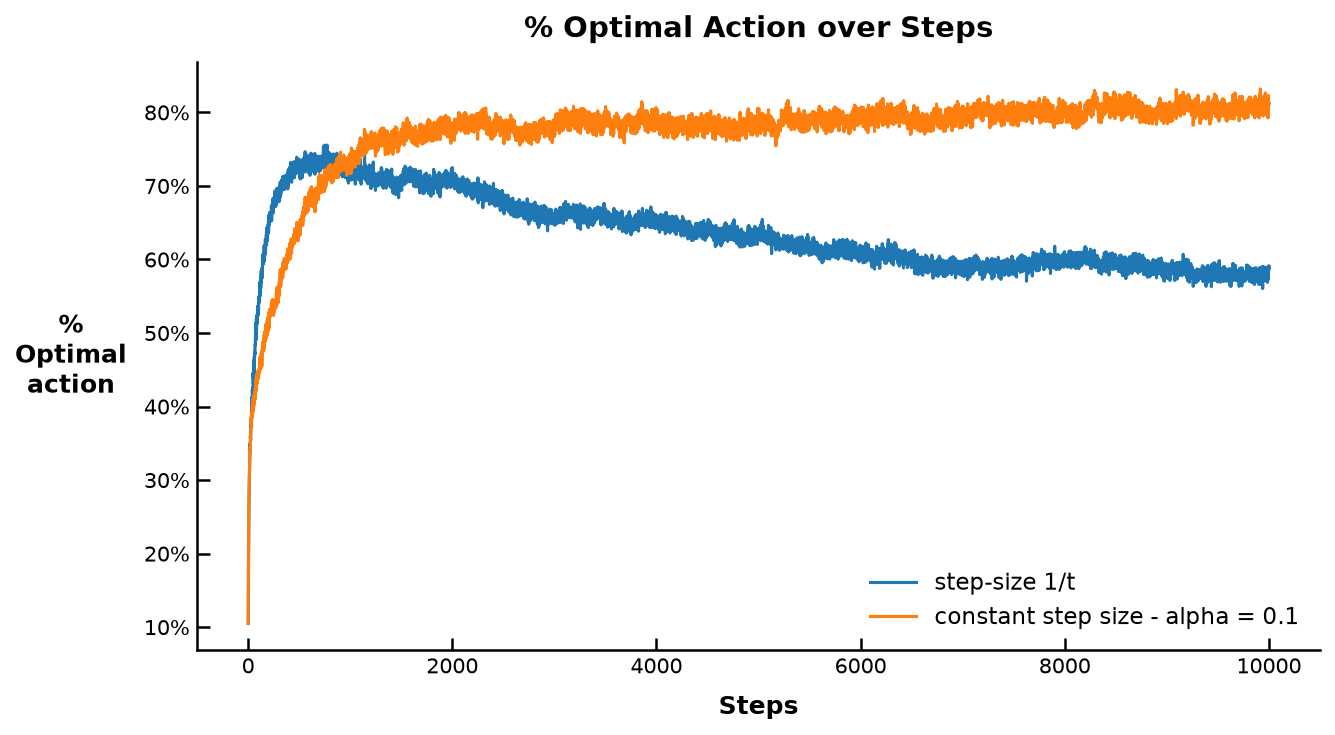

In [6]:
fig_optimal, ax_optimal = plot_bandit_performance(
    metrics_data=optimal_actions_dict,
    metric_type="optimal_action",
    title="% Optimal Action over Steps",
    colors=custom_colors
)
plt.show()

## Observations:
- This plot makes the non-stationary tracking problem even clearer than the reward curve above. The sample-average agent (step-size 1/t) initially catches up fast and even leads early on, peaking at around 70–72% optimal-action selection near step 1000. However, past this point its performance steadily **declines**, dropping to around 58% by the end of the run. This happens because its step size keeps shrinking as t grows, making it slower and slower to adapt as the true optimal action keeps changing — it becomes anchored to outdated estimates.
- The constant step-size agent (α = 0.1), on the other hand, continues to improve throughout the run and stabilizes at a much higher ~80% optimal-action rate. Because it never lets its step size decay, it retains a consistent ability to adapt to the drifting environment, allowing it to keep re-identifying the current optimal action as the environment changes. This is one of the clearest illustrations of why constant step sizes are preferred over sample averages in non-stationary settings.